# DuckDB 101 — Flight Delays Demo

**Dataset:** US Airline On-Time Performance — Bureau of Transportation Statistics (BTS)  
**Years:** 2022, 2023, 2024 · ~21 million flights  
**Tables:** `flights` · `airlines` · `airports`

> Ducks tracking other flying objects.

## Setup

In [4]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

DATA = Path('../data/flights')

con = duckdb.connect()
print('DuckDB', duckdb.__version__)

DuckDB 1.5.3


---
## 1. Reading Files Directly

No loading, no servers, no ETL. Just point DuckDB at a file.

In [5]:
# Read a CSV directly — no import step
con.sql(f"SELECT * FROM '{DATA}/flights_2023.csv' LIMIT 5").df()

,FlightDate,Reporting_Airline,Origin,Dest,DepDelay,DepDelayMinutes,DepDel15,ArrDelay,ArrDelayMinutes,ArrDel15,...,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2023-01-02,9E,BDL,LGA,-3.0,0.0,0.0,-12.0,0.0,0.0,...,0.0,65.0,56.0,25.0,101.0,NaN,NaN,NaN,NaN,NaN
1,2023-01-03,9E,BDL,LGA,-5.0,0.0,0.0,-8.0,0.0,0.0,...,0.0,65.0,62.0,37.0,101.0,NaN,NaN,NaN,NaN,NaN
2,2023-01-04,9E,BDL,LGA,-5.0,0.0,0.0,-21.0,0.0,0.0,...,0.0,65.0,49.0,28.0,101.0,NaN,NaN,NaN,NaN,NaN
3,2023-01-05,9E,BDL,LGA,-6.0,0.0,0.0,-17.0,0.0,0.0,...,0.0,65.0,54.0,38.0,101.0,NaN,NaN,NaN,NaN,NaN
4,2023-01-06,9E,BDL,LGA,-1.0,0.0,0.0,-16.0,0.0,0.0,...,0.0,65.0,50.0,28.0,101.0,NaN,NaN,NaN,NaN,NaN


In [6]:
# Inspect the schema
con.sql(f"DESCRIBE SELECT * FROM '{DATA}/flights_2023.csv'").df()

,column_name,column_type,null,key,default,extra
0,FlightDate,DATE,YES,None,None,None
1,Reporting_Airline,VARCHAR,YES,None,None,None
2,Origin,VARCHAR,YES,None,None,None
3,Dest,VARCHAR,YES,None,None,None
4,DepDelay,DOUBLE,YES,None,None,None
5,DepDelayMinutes,DOUBLE,YES,None,None,None
6,DepDel15,DOUBLE,YES,None,None,None
7,ArrDelay,DOUBLE,YES,None,None,None
8,ArrDelayMinutes,DOUBLE,YES,None,None,None
9,ArrDel15,DOUBLE,YES,None,None,None


In [7]:
# Instant data profile
con.sql(f"SUMMARIZE SELECT * FROM '{DATA}/flights_2023.csv'").df()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,FlightDate,DATE,2023-01-01,2023-12-31,414,2023-07-03 19:27:34.589765,NaN,2023-04-06,2023-07-06,2023-10-01,6847899,0.00
1,Reporting_Airline,VARCHAR,9E,YX,15,NaN,NaN,NaN,NaN,NaN,6847899,0.00
2,Origin,VARCHAR,ABE,YUM,387,NaN,NaN,NaN,NaN,NaN,6847899,0.00
3,Dest,VARCHAR,ABE,YUM,387,NaN,NaN,NaN,NaN,NaN,6847899,0.00
4,DepDelay,DOUBLE,-99.0,4413.0,2126,12.285453553479996,55.32858321215052,-5.33265320602421,-2.0,9.176811668651258,6847899,1.23
5,DepDelayMinutes,DOUBLE,0.0,4413.0,2126,15.386552709669884,54.337353928055734,0.0,0.0,9.18516924022156,6847899,1.23
6,DepDel15,DOUBLE,0.0,1.0,2,0.2052754765745479,0.40390280936430595,0.0,0.0,0.0,6847899,1.23
7,ArrDelay,DOUBLE,-119.0,4405.0,2219,6.627152492591648,57.078925627461885,-14.984685867853273,-5.706500583733858,9.252193897555737,6847899,1.53
8,ArrDelayMinutes,DOUBLE,0.0,4405.0,2219,15.231401712162242,53.86249649097045,0.0,0.0,9.229648369625716,6847899,1.53
9,ArrDel15,DOUBLE,0.0,1.0,2,0.20563786562956418,0.4041669928045813,0.0,0.0,0.0,6847899,1.53


---
## 2. DuckDB Superpowers

### Read multiple files with a glob — no UNION needed

In [8]:
# All 3 years, one query
con.sql(f"""
    SELECT
        year(FlightDate::DATE)  AS year,
        COUNT(*)                AS total_flights,
        SUM(Cancelled)          AS cancellations
    FROM '{DATA}/flights_*.csv'
    GROUP BY year
    ORDER BY year
""").df()

,year,total_flights,cancellations
0,2022,6729125,181286.0
1,2023,6847899,87943.0
2,2024,7079061,96315.0


In [9]:
# EXCLUDE — drop columns you don't want without listing everything else
con.sql(f"""
    SELECT * EXCLUDE (CRSElapsedTime, ActualElapsedTime, AirTime, DepDel15, ArrDel15)
    FROM '{DATA}/flights_2023.csv'
    LIMIT 5
""").df()

,FlightDate,Reporting_Airline,Origin,Dest,DepDelay,DepDelayMinutes,ArrDelay,ArrDelayMinutes,Cancelled,CancellationCode,Diverted,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2023-01-02,9E,BDL,LGA,-3.0,0.0,-12.0,0.0,0.0,None,0.0,101.0,NaN,NaN,NaN,NaN,NaN
1,2023-01-03,9E,BDL,LGA,-5.0,0.0,-8.0,0.0,0.0,None,0.0,101.0,NaN,NaN,NaN,NaN,NaN
2,2023-01-04,9E,BDL,LGA,-5.0,0.0,-21.0,0.0,0.0,None,0.0,101.0,NaN,NaN,NaN,NaN,NaN
3,2023-01-05,9E,BDL,LGA,-6.0,0.0,-17.0,0.0,0.0,None,0.0,101.0,NaN,NaN,NaN,NaN,NaN
4,2023-01-06,9E,BDL,LGA,-1.0,0.0,-16.0,0.0,0.0,None,0.0,101.0,NaN,NaN,NaN,NaN,NaN


---
## 3. Load the Three Tables

```
flights ──── Reporting_Airline ──▶ airlines (IATA_CODE)
flights ──── Origin / Dest     ──▶ airports (IATA_CODE)
```

In [10]:
con.sql(f"CREATE OR REPLACE TABLE airlines AS SELECT * FROM '{DATA}/airlines.csv'")
con.sql(f"CREATE OR REPLACE TABLE airports AS SELECT * FROM '{DATA}/airports.csv'")
con.sql(f"CREATE OR REPLACE TABLE flights  AS SELECT * FROM '{DATA}/flights_*.csv'")

con.sql("SELECT table_name, estimated_size FROM duckdb_tables()").df()

,table_name,estimated_size
0,airlines,28
1,airports,873
2,flights,20656085


---
## 4. Basic Aggregations

In [11]:
# On-time performance by airline
con.sql("""
    SELECT
        al.AIRLINE,
        COUNT(*)                                          AS total_flights,
        ROUND(AVG(f.ArrDelay), 1)                         AS avg_arr_delay_min,
        ROUND(SUM(f.Cancelled) * 100.0 / COUNT(*), 1)    AS cancel_pct
    FROM flights f
    JOIN airlines al ON f.Reporting_Airline = al.IATA_CODE
    WHERE f.Cancelled = 0
    GROUP BY al.AIRLINE
    ORDER BY avg_arr_delay_min DESC
""").df()

,AIRLINE,total_flights,avg_arr_delay_min,cancel_pct
0,Frontier Airlines,528584,16.8,0.0
1,JetBlue Airways,768475,16.0,0.0
2,Allegiant Air,342716,14.4,0.0
3,American Airlines,2747858,12.7,0.0
4,Spirit Airlines,740917,11.1,0.0
5,Hawaiian Airlines,230807,7.6,0.0
6,PSA Airlines,623631,6.7,0.0
7,Southwest Airlines,4096281,6.0,0.0
8,United Airlines,2084502,5.8,0.0
9,SkyWest Airlines,2123287,5.8,0.0


In [12]:
# Monthly delay trend across all 3 years
monthly = con.sql("""
    SELECT
        strftime(FlightDate::DATE, '%Y-%m') AS month,
        COUNT(*)                             AS flights,
        ROUND(AVG(ArrDelay), 1)              AS avg_arr_delay
    FROM flights
    WHERE Cancelled = 0
    GROUP BY month
    ORDER BY month
""").df()

monthly.head(10)

,month,flights,avg_arr_delay
0,2022-01,504646,4.0
1,2022-02,473977,4.7
2,2022-03,556111,7.1
3,2022-04,543460,8.6
4,2022-05,567434,7.4
5,2022-06,559407,10.7
6,2022-07,584411,9.9
7,2022-08,575409,8.7
8,2022-09,548795,2.4
9,2022-10,567455,2.1


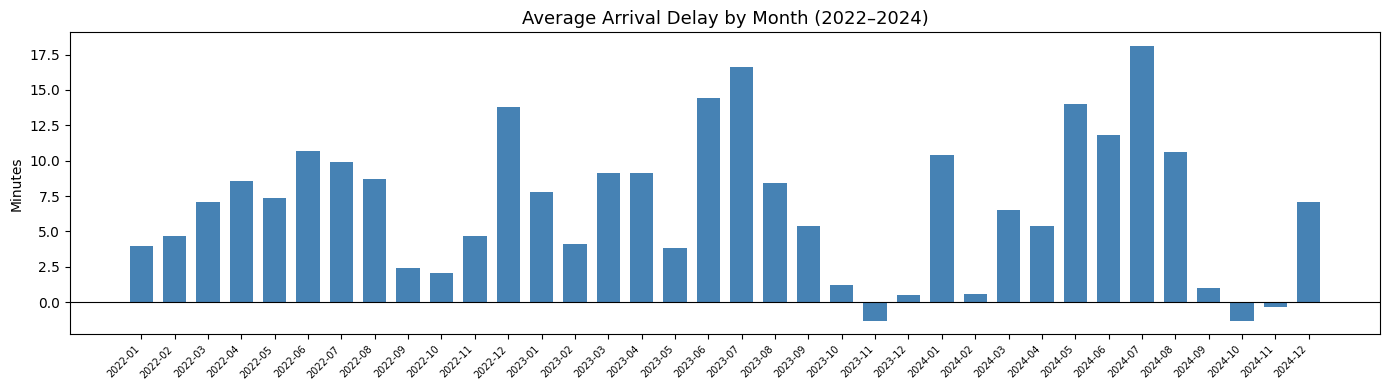

In [13]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly['month'], monthly['avg_arr_delay'], color='steelblue', width=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Arrival Delay by Month (2022–2024)', fontsize=13)
ax.set_ylabel('Minutes')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

---
## 5. What's Actually Causing Delays?

In [14]:
con.sql("""
    SELECT
        al.AIRLINE,
        ROUND(AVG(f.CarrierDelay), 1)      AS carrier,
        ROUND(AVG(f.WeatherDelay), 1)      AS weather,
        ROUND(AVG(f.NASDelay), 1)          AS air_system,
        ROUND(AVG(f.LateAircraftDelay), 1) AS late_aircraft,
        ROUND(AVG(f.SecurityDelay), 1)     AS security
    FROM flights f
    JOIN airlines al ON f.Reporting_Airline = al.IATA_CODE
    WHERE f.ArrDelay > 0 AND f.Cancelled = 0
    GROUP BY al.AIRLINE
    ORDER BY carrier DESC
""").df()

,AIRLINE,carrier,weather,air_system,late_aircraft,security
0,SkyWest Airlines,43.8,11.7,7.2,17.1,0.2
1,Delta Air Lines,35.2,3.4,12.3,20.1,0.1
2,JetBlue Airways,33.4,2.1,14.2,30.5,0.1
3,American Airlines,29.1,4.0,11.2,38.4,0.2
4,Endeavor Air,25.4,6.0,19.0,28.0,0.0
5,Hawaiian Airlines,25.3,1.4,1.8,17.9,0.2
6,Allegiant Air,24.4,6.9,15.4,30.7,0.2
7,United Airlines,23.4,3.4,15.6,29.2,0.0
8,PSA Airlines,22.9,6.2,11.5,36.8,0.2
9,Frontier Airlines,22.9,1.7,14.2,38.0,0.0


---
## 6. The Southwest December 2022 Story

Southwest cancelled ~16,700 flights in one week. Let's find it.

In [15]:
wn = con.sql("""
    SELECT
        al.AIRLINE,
        strftime(FlightDate::DATE, '%Y-%m') AS month,
        COUNT(*)                             AS flights,
        SUM(Cancelled)                       AS cancellations,
        ROUND(SUM(Cancelled) * 100.0 / COUNT(*), 1) AS cancel_pct
    FROM flights f
    JOIN airlines al ON f.Reporting_Airline = al.IATA_CODE
    WHERE al.AIRLINE = 'Southwest Airlines'
    GROUP BY al.AIRLINE, month
    ORDER BY month
""").df()

wn

,AIRLINE,month,flights,cancellations,cancel_pct
0,Southwest Airlines,2022-01,97436,6448.0,6.6
1,Southwest Airlines,2022-02,90965,3779.0,4.2
2,Southwest Airlines,2022-03,103720,2048.0,2.0
3,Southwest Airlines,2022-04,102931,1941.0,1.9
4,Southwest Airlines,2022-05,108027,809.0,0.7
5,Southwest Airlines,2022-06,111002,1296.0,1.2
6,Southwest Airlines,2022-07,117844,1843.0,1.6
7,Southwest Airlines,2022-08,118889,3157.0,2.7
8,Southwest Airlines,2022-09,112410,1983.0,1.8
9,Southwest Airlines,2022-10,116520,1369.0,1.2


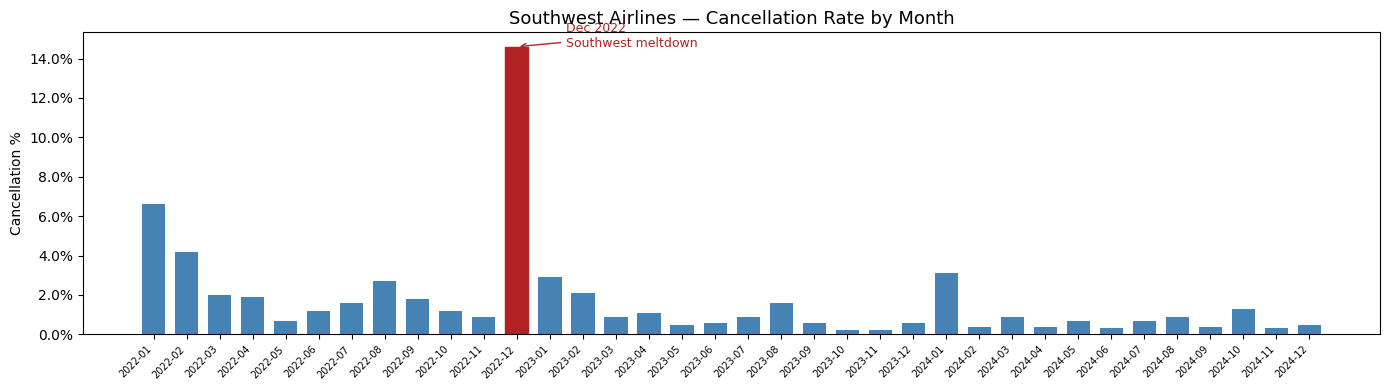

In [16]:
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(wn['month'], wn['cancel_pct'], color='steelblue', width=0.7)

# Highlight December 2022
for i, m in enumerate(wn['month']):
    if m == '2022-12':
        bars[i].set_color('firebrick')
        ax.annotate('Dec 2022\nSouthwest meltdown',
                    xy=(i, wn['cancel_pct'].iloc[i]),
                    xytext=(i + 1.5, wn['cancel_pct'].iloc[i]),
                    fontsize=9, color='firebrick',
                    arrowprops=dict(arrowstyle='->', color='firebrick'))

ax.set_title('Southwest Airlines — Cancellation Rate by Month', fontsize=13)
ax.set_ylabel('Cancellation %')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

---
## 7. Worst Airports to Depart From

In [17]:
con.sql("""
    SELECT
        ap.iata_code,
        ap.name,
        ap.municipality || ', ' || ap.iso_region AS location,
        COUNT(*)                        AS departures,
        ROUND(AVG(f.DepDelay), 1)       AS avg_dep_delay,
        ROUND(SUM(f.Cancelled) * 100.0 / COUNT(*), 1) AS cancel_pct
    FROM flights f
    JOIN airports ap ON f.Origin = ap.iata_code
    WHERE f.Cancelled = 0
    GROUP BY ap.iata_code, ap.name, location
    HAVING departures > 10000
    ORDER BY avg_dep_delay DESC
    LIMIT 15
""").df()

,iata_code,name,location,departures,avg_dep_delay,cancel_pct
0,ASE,Aspen-Pitkin County Airport (Sardy Field),"Aspen, US-CO",19349,25.5,0.0
1,FLL,Fort Lauderdale Hollywood International Airport,"Fort Lauderdale, US-FL",260406,19.3,0.0
2,JAC,Jackson Hole Airport,"Jackson, US-WY",15352,19.3,0.0
3,MIA,Miami International Airport,"Miami, US-FL",313421,18.3,0.0
4,MCO,Orlando International Airport,"Orlando, US-FL",460464,18.1,0.0
5,EYW,Key West International Airport,"Key West, US-FL",22384,18.1,0.0
6,PBI,Palm Beach International Airport,"West Palm Beach, US-FL",79474,18.0,0.0
7,DFW,Dallas Fort Worth International Airport,"Dallas-Fort Worth, US-TX",857369,16.4,0.0
8,BWI,Baltimore/Washington International Thurgood Ma...,"Baltimore, US-MD",276152,16.3,0.0
9,EWR,Newark Liberty International Airport,"Newark, US-NJ",384128,15.8,0.0


---
## 8. Export to Parquet

Parquet is columnar — smaller files, faster queries.

In [18]:
import time, os

parquet_path = str(DATA / 'flights_all.parquet')

t0 = time.time()
con.sql(f"COPY flights TO '{parquet_path}' (FORMAT PARQUET)")
print(f'Written in {time.time()-t0:.1f}s')

csv_size  = sum(os.path.getsize(DATA / f'flights_{y}.csv') for y in [2022,2023,2024] if (DATA / f'flights_{y}.csv').exists())
parq_size = os.path.getsize(parquet_path)
print(f'CSV total:  {csv_size/1e6:.0f} MB')
print(f'Parquet:    {parq_size/1e6:.0f} MB  ({parq_size/csv_size*100:.0f}% of CSV size)')

Written in 20.2s
CSV total:  2119 MB
Parquet:    228 MB  (11% of CSV size)


In [19]:
# Speed comparison — same query on CSV vs Parquet
query = """
    SELECT Reporting_Airline, COUNT(*), ROUND(AVG(ArrDelay),1)
    FROM '{source}'
    WHERE Cancelled = 0
    GROUP BY Reporting_Airline
"""

t0 = time.time()
con.sql(query.format(source=str(DATA / 'flights_*.csv'))).df()
csv_time = time.time() - t0

t0 = time.time()
con.sql(query.format(source=parquet_path)).df()
parq_time = time.time() - t0

print(f'CSV:     {csv_time:.2f}s')
print(f'Parquet: {parq_time:.2f}s  ({csv_time/parq_time:.1f}x faster)')

CSV:     4.17s
Parquet: 0.33s  (12.5x faster)


---
## 9. Bonus: Remote Files via httpfs

DuckDB can query files directly from S3 — no download, no server.

In [20]:
# Same SQL, but the file lives on S3 — no download, no import
# Dataset: NYC Yellow Taxi 2019 (~84M rows) — public bucket, no credentials needed
con.sql('INSTALL httpfs; LOAD httpfs;')

con.sql("""
    SELECT
        passenger_count,
        COUNT(*)                        AS trips,
        ROUND(AVG(trip_distance), 2)    AS avg_distance_mi,
        ROUND(AVG(total_amount), 2)     AS avg_fare_usd
    FROM read_parquet('s3://duckplyr-demo-taxi-data/taxi-data-2019-partitioned/*/*.parquet')
    WHERE passenger_count > 0
    GROUP BY passenger_count
    ORDER BY passenger_count
""").df()

,passenger_count,trips,avg_distance_mi,avg_fare_usd
0,1,59105216,2.94,18.93
1,2,12784945,3.13,19.59
2,3,3583689,3.08,19.35
3,4,1709710,3.16,19.76
4,5,3397921,3.03,18.91
5,6,2038806,3.02,18.84
6,7,416,3.25,64.87
7,8,277,5.36,71.13
8,9,225,5.24,67.99
